# InsurPrime: Can You Guess the Insurance Premium?
by Crédit Agricole Assurances

## Model: Histogram Gradient Boosting

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import TweedieRegressor

In [2]:
from feature_eng import add_engineered_features
from data_preprocessing import preprocess_data

### Data Loading

In [3]:
X_train=pd.read_csv("Data/x-train.csv")
y_train=pd.read_csv("Data/y-train.csv")
X_test=pd.read_csv("Data/x-test.csv")

/tmp/ipykernel_1460100/1278827676.py:1: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_train=pd.read_csv("Data/x-train.csv")
/tmp/ipykernel_1460100/1278827676.py:3: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_test=pd.read_csv("Data/x-test.csv")


In [4]:
test_ids = X_test["ID"].copy()
test_exposure = X_test["ANNEE_ASSURANCE"]

### Data Preprocessing

In [5]:
X_train_clean, y_train_clean, fitted = preprocess_data(
    X_train, 
    y_train, 
    is_train=True
)

X_test_clean, _, _ = preprocess_data(
    X_test, 
    is_train=False,
    fitted_transformers=fitted
)

### Feature Engineering

In [6]:
# train
X_train_fe, fe_meta = add_engineered_features(X_train_clean, is_train=True)

# test
X_test_fe, _ = add_engineered_features(X_test_clean, is_train=False, feature_meta=fe_meta)

### Histogram Gradient Boosting

In [7]:
## Combine train + test for consistent encoding

n_train = len(X_train_fe)
X_combined = pd.concat([X_train_fe, X_test_fe], axis=0, ignore_index=True)

# categorical columns
cat_cols = X_combined.select_dtypes(include=["object", "category"]).columns.tolist()

# Ordinal encode cat cols
# Cast to string so NaNs become 'nan' and are treated as a level
if len(cat_cols) > 0:
    ord_enc = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )
    X_combined[cat_cols] = ord_enc.fit_transform(X_combined[cat_cols].astype(str))

# everything is numeric
X_train_enc = X_combined.iloc[:n_train].copy()
X_test_enc  = X_combined.iloc[n_train:].copy()

# Indices of categorical features
cat_indices = [X_train_enc.columns.get_loc(c) for c in cat_cols]


## Train/val

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_enc,
    y_train_clean,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

# Exposure (ANNEE_ASSURANCE) as sample_weight and for charge computation
w_tr  = pd.to_numeric(X_tr["ANNEE_ASSURANCE"], errors="coerce").fillna(0).clip(lower=0)
w_val = pd.to_numeric(X_val["ANNEE_ASSURANCE"], errors="coerce").fillna(0).clip(lower=0)

In [8]:
## frequency model = > Poisson

y_tr_freq = y_tr["FREQ"].astype(float)

# Parameters
params_freq = {
    "min_samples_leaf": 50,
    "max_leaf_nodes": 31,
    "max_iter": 2000,
    "learning_rate": 0.05,
    "l2_regularization": 5.0,
    "loss": "poisson",
}

freq_model = HistGradientBoostingRegressor(
    **params_freq,
    categorical_features=cat_indices,
    random_state=42
)

freq_model.fit(X_tr, y_tr_freq, sample_weight=w_tr)

pred_freq_val = np.clip(freq_model.predict(X_val), 0, None)


## Severity model => Gamma

mask_claim_tr = y_tr["CHARGE"] > 0
X_tr_sev = X_tr[mask_claim_tr].copy()
y_tr_sev = y_tr.loc[mask_claim_tr, "CM"].astype(float)
y_tr_sev = np.maximum(y_tr_sev, 1.0)  # Gamma : y > 0

params_sev = {
    "min_samples_leaf": 150,
    "max_leaf_nodes": 63,
    "max_iter": 1000,
    "learning_rate": 0.01,
    "l2_regularization": 5.0,
    "loss": "gamma",
}

sev_model = HistGradientBoostingRegressor(
    **params_sev,
    categorical_features=cat_indices,
    random_state=42
)
sev_model.fit(X_tr_sev, y_tr_sev)

pred_sev_val = sev_model.predict(X_val)

# Clip severity
limit_sev_val = y_tr_sev.quantile(0.999) * 2.0
pred_sev_val = np.clip(pred_sev_val, 0, limit_sev_val)


## Val CHARGE and RMSE

pred_charge_val = pred_freq_val * pred_sev_val * w_val

rmse_val = np.sqrt(mean_squared_error(y_val["CHARGE"], pred_charge_val))
print(f"Validation RMSE: {rmse_val:,.2f}")

Validation RMSE: 7,041.14


In [9]:
## Train on full train and predict on test

print("\n Training ensemble on FULL data and scoring test ")

w_full  = pd.to_numeric(X_train_enc["ANNEE_ASSURANCE"], errors="coerce").fillna(0).clip(lower=0)
y_full_freq = y_train_clean["FREQ"].astype(float)

mask_claim_full = y_train_clean["CHARGE"] > 0
X_full_sev      = X_train_enc[mask_claim_full].copy()
y_full_sev      = y_train_clean.loc[mask_claim_full, "CM"].astype(float)
y_full_sev      = np.maximum(y_full_sev, 1.0)

n_bags = 5
preds_freq_test = np.zeros(len(X_test_enc))
preds_sev_test  = np.zeros(len(X_test_enc))

for i in range(n_bags):
    seed = 42 + i
    print(f"Bag {i+1}/{n_bags}...")

    # Frequency
    model_freq = HistGradientBoostingRegressor(
        **params_freq,
        categorical_features=cat_indices,
        random_state=seed
    )
    model_freq.fit(X_train_enc, y_full_freq, sample_weight=w_full)
    preds_freq_test += model_freq.predict(X_test_enc)

    # Severity
    model_sev = HistGradientBoostingRegressor(
        **params_sev,
        categorical_features=cat_indices,
        random_state=seed
    )
    model_sev.fit(X_full_sev, y_full_sev)
    preds_sev_test += model_sev.predict(X_test_enc)

# Average the bagged predictions
preds_freq_test /= n_bags
preds_sev_test  /= n_bags

# Clip predictions
preds_freq_test = np.clip(preds_freq_test, 0, None)
limit_sev_full = y_full_sev.quantile(0.999) * 2.0
preds_sev_test = np.clip(preds_sev_test, 0, limit_sev_full)

# Final charge = freq * severity * exposure
test_exposure_clean = pd.to_numeric(test_exposure, errors="coerce").fillna(0).clip(lower=0)
pred_charge_test = preds_freq_test * preds_sev_test * test_exposure_clean.to_numpy(dtype=float)


## submission

submission = pd.DataFrame({
    "ID": test_ids,
    "FREQ": preds_freq_test,
    "CM": preds_sev_test,
    "ANNEE_ASSURANCE": test_exposure_clean,
    "CHARGE": pred_charge_test,
})

submission.to_csv("Submissions/submission_hgbr.csv", index=False)
print("\nSaved submission_hgbr.csv")
print(submission.head())


 Training ensemble on FULL data and scoring test 
Bag 1/5...
Bag 2/5...
Bag 3/5...
Bag 4/5...
Bag 5/5...

Saved submission_hgbr.csv
       ID      FREQ            CM  ANNEE_ASSURANCE      CHARGE
0  383611  0.024266  10760.138242         0.813699  212.463435
1  383612  0.006372   3591.240077         1.000000   22.882571
2  383613  0.004696   8094.434628         0.586301   22.287777
3  383614  0.002446  18566.637773         1.000000   45.423161
4  383615  0.004478  21081.160789         0.753425   71.129768


We observe that the validation RMSE is quite high (RMSE = 7041.14) which is much bigger than the benchmark RMSE = 5617.62. However, we get a much better RMSE on the test dataset : RMSE = 5598.75. 

The high validation RMSE probably arises from random variation from a few large claims falling into the validation split, which makes the metric very unstable in rare-event, heavy-tailed data.
The test RMSE is much lower and beats the benchmark, meaning the model actually generalizes well and is performing strongly.

### Useful graphs to understand the model

In [10]:
df_val = pd.DataFrame({
    "charge_true": y_val["CHARGE"].values,
    "charge_pred": pred_charge_val,
    "freq_pred":   pred_freq_val,
    "sev_pred":    pred_sev_val,
    "exposure":    w_val.values,
})

# Derived columns
df_val["has_claim"]   = (df_val["charge_true"] > 0).astype(int)
df_val["sev_true"]    = np.where(df_val["has_claim"] == 1,
                                 df_val["charge_true"] / df_val["exposure"].replace(0, np.nan),
                                 np.nan)
df_val["log_true"]    = np.log1p(df_val["charge_true"])
df_val["log_pred"]    = np.log1p(df_val["charge_pred"])
df_val["log_resid"]   = df_val["log_true"] - df_val["log_pred"]

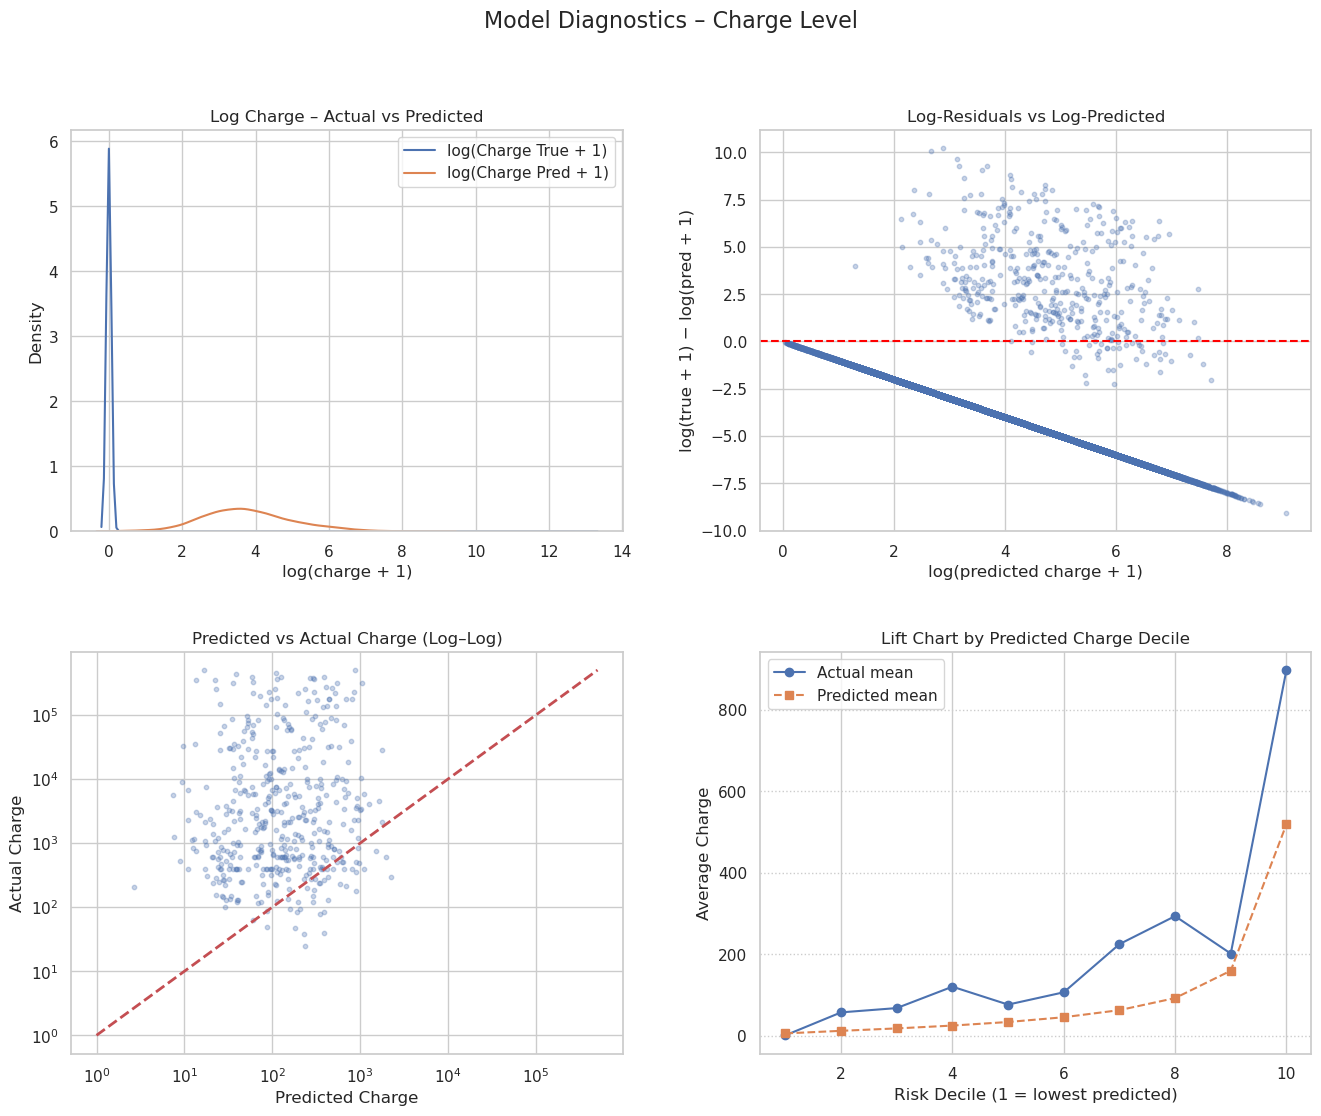

In [11]:
## CHARGE

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Model Diagnostics – Charge Level", fontsize=16)
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# (1,1) Log(actual) vs Log(pred) densities
ax = axes[0, 0]
sns.kdeplot(df_val["log_true"], label="log(Charge True + 1)", ax=ax)
sns.kdeplot(df_val["log_pred"], label="log(Charge Pred + 1)", ax=ax)
ax.set_title("Log Charge – Actual vs Predicted")
ax.set_xlabel("log(charge + 1)")
ax.legend()

# (1,2) Log-residuals vs log-predicted
ax = axes[0, 1]
ax.scatter(df_val["log_pred"], df_val["log_resid"], alpha=0.3, s=10)
ax.axhline(0, color="red", linestyle="--")
ax.set_title("Log-Residuals vs Log-Predicted")
ax.set_xlabel("log(predicted charge + 1)")
ax.set_ylabel("log(true + 1) − log(pred + 1)")

# (2,1) Predicted vs Actual charge (log–log)
ax = axes[1, 0]
mask_pos = df_val["charge_true"] > 0
ax.scatter(df_val.loc[mask_pos, "charge_pred"],
           df_val.loc[mask_pos, "charge_true"],
           alpha=0.3, s=10)
max_val = max(df_val["charge_pred"].max(), df_val["charge_true"].max())
ax.plot([1, max_val], [1, max_val], "r--", linewidth=2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Predicted vs Actual Charge (Log–Log)")
ax.set_xlabel("Predicted Charge")
ax.set_ylabel("Actual Charge")

# (2,2) Decile lift chart
ax = axes[1, 1]
# Rank by predicted charge and split into 10 groups
df_val_sorted = df_val.sort_values("charge_pred").reset_index(drop=True)
df_val_sorted["decile"] = pd.qcut(
    df_val_sorted.index,
    q=10,
    labels=False
)

decile_stats = df_val_sorted.groupby("decile")[["charge_true", "charge_pred"]].mean()
x = np.arange(1, 11)

ax.plot(x, decile_stats["charge_true"], marker="o", label="Actual mean")
ax.plot(x, decile_stats["charge_pred"], marker="s", linestyle="--", label="Predicted mean")
ax.set_title("Lift Chart by Predicted Charge Decile")
ax.set_xlabel("Risk Decile (1 = lowest predicted)")
ax.set_ylabel("Average Charge")
ax.legend()
ax.grid(axis="y", linestyle=":")

plt.show()

- Log Charge – Actual vs Predicted:

Actual log-charges are extremely concentrated near zero (as seen in EDA) because most policies have no claims. However, predicted log-charges show a wider and smoother distribution. This suggests the model spreads risk more evenly than the true data.

- Log-Residuals vs Log-Predicted:

Residuals become increasingly negative as predicted charge increases so the model underpredicts high charges. The horizontal line at 0 shows unbiased predictions would scatter symmetrically around it but here they do not. Therefore, we observe that the model is not well calibrated at the high end.

- Predicted vs Actual Charge (Log–Log):

Most large actual claims lie above the diagonal so model systematically underestimates big losses. Predictions cluster in mid-range while actual charges span several orders of magnitude. Heavy-tail behavior is not fully captured by the current model.

- Lift Chart by Predicted Charge Decile:

Rising actual mean across deciles shows the model can differentiate low- vs high-risk policies. But predicted means grow much more slowlyso the model under-ranks the highest-risk group. Decile 10 gap confirms underestimation of the very top risks.

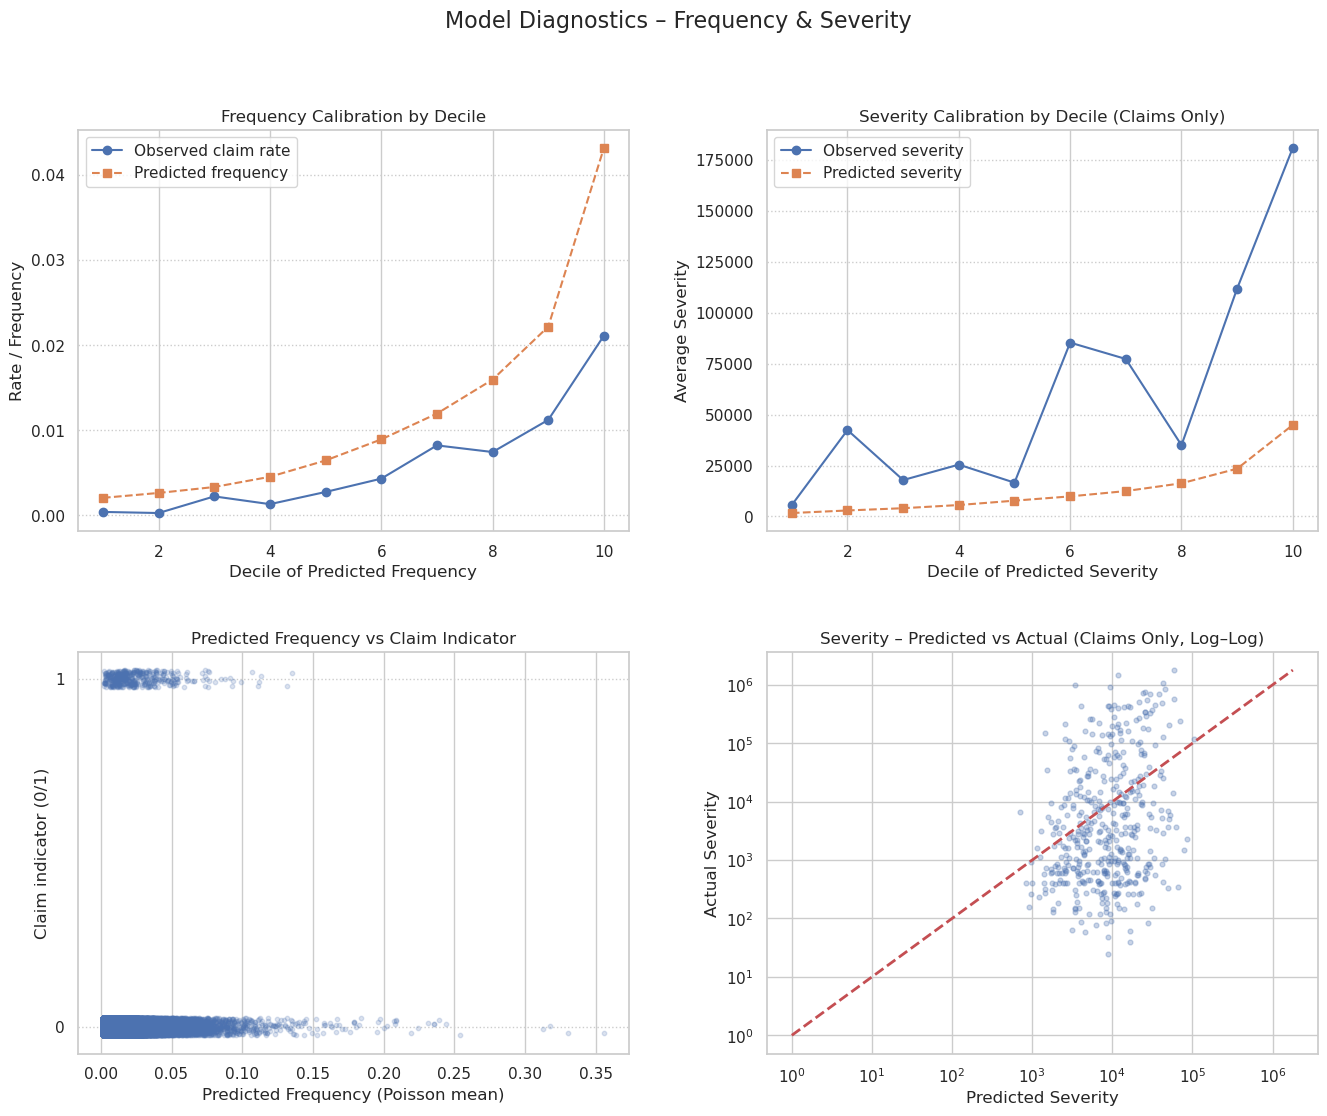

In [12]:
## FREQUENCY & SEVERITY

fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle("Model Diagnostics – Frequency & Severity", fontsize=16)
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# (1,1) Frequency calibration by decile
ax = axes2[0, 0]

df_freq = df_val.copy()
df_freq_sorted = df_freq.sort_values("freq_pred").reset_index(drop=True)
df_freq_sorted["decile"] = pd.qcut(
    df_freq_sorted.index,
    q=10,
    labels=False
)

# Observed frequency = mean(has_claim) / mean(exposure)? or just mean(has_claim)
# Here: observed claim probability per decile
freq_stats = df_freq_sorted.groupby("decile").agg(
    obs_rate=("has_claim", "mean"),
    pred_rate=("freq_pred", "mean"),
)

x = np.arange(1, 11)
ax.plot(x, freq_stats["obs_rate"], marker="o", label="Observed claim rate")
ax.plot(x, freq_stats["pred_rate"], marker="s", linestyle="--", label="Predicted frequency")
ax.set_title("Frequency Calibration by Decile")
ax.set_xlabel("Decile of Predicted Frequency")
ax.set_ylabel("Rate / Frequency")
ax.legend()
ax.grid(axis="y", linestyle=":")

# (1,2) Severity calibration by decile (claims only)
ax = axes2[0, 1]

df_sev = df_val[df_val["has_claim"] == 1].copy()
# Guard against empty
if len(df_sev) > 0:
    df_sev_sorted = df_sev.sort_values("sev_pred").reset_index(drop=True)
    df_sev_sorted["decile"] = pd.qcut(
        df_sev_sorted.index,
        q=10,
        labels=False
    )

    sev_stats = df_sev_sorted.groupby("decile").agg(
        obs_sev=("sev_true", "mean"),
        pred_sev=("sev_pred", "mean"),
    )

    x = np.arange(1, 11)
    ax.plot(x, sev_stats["obs_sev"], marker="o", label="Observed severity")
    ax.plot(x, sev_stats["pred_sev"], marker="s", linestyle="--", label="Predicted severity")
    ax.set_title("Severity Calibration by Decile (Claims Only)")
    ax.set_xlabel("Decile of Predicted Severity")
    ax.set_ylabel("Average Severity")
    ax.legend()
    ax.grid(axis="y", linestyle=":")
else:
    ax.text(0.5, 0.5, "No positive claims in validation set",
            ha="center", va="center")
    ax.set_axis_off()

# (2,1) Predicted frequency vs observed claim indicator
ax = axes2[1, 0]

jitter = (np.random.rand(len(df_val)) - 0.5) * 0.05
ax.scatter(df_val["freq_pred"], df_val["has_claim"] + jitter,
           alpha=0.2, s=10)
ax.set_title("Predicted Frequency vs Claim Indicator")
ax.set_xlabel("Predicted Frequency (Poisson mean)")
ax.set_ylabel("Claim indicator (0/1)")
ax.set_yticks([0, 1])
ax.grid(axis="y", linestyle=":")

# (2,2) Severity scatter (claims only, log–log) ===
ax = axes2[1, 1]
if len(df_sev) > 0:
    ax.scatter(df_sev["sev_pred"], df_sev["sev_true"],
               alpha=0.3, s=12)
    max_sev_val = max(df_sev["sev_pred"].max(), df_sev["sev_true"].max())
    ax.plot([1, max_sev_val], [1, max_sev_val], "r--", linewidth=2)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title("Severity – Predicted vs Actual (Claims Only, Log–Log)")
    ax.set_xlabel("Predicted Severity")
    ax.set_ylabel("Actual Severity")
else:
    ax.text(0.5, 0.5, "No positive claims in validation set",
            ha="center", va="center")
    ax.set_axis_off()

plt.show()

- Frequency Calibration by Decile

Predicted frequency increases smoothly across deciles, showing good ranking ability. However, predicted rates are consistently higher than observed claim rates. This indicates systematic overestimation of frequency, especially in the top deciles.

- Severity Calibration by Decile (Claims Only)

Observed severity is very noisy and jumps sharply in the top decile, reflecting extreme heavy-tailed claims. Predicted severity grows smoothly but stays far below actual values, especially in high-risk groups. The model is underestimating large losses and lacks tail calibration.

- Predicted Frequency vs Claim Indicator

Most predicted frequencies are near zero, consistent with the extremely rare-event nature of fire claims. Claim cases (1’s) vertically align at low predicted frequencies so the model fails to separate claim vs non-claim. Frequency model barely distinguishes risky farms from normal ones.

- Severity – Predicted vs Actual (Claims Only, Log–Log)

Points mostly sit above the diagonal, showing heavy underestimation of true severities. Predicted severities span a narrow range, while actual severities span 5+ orders of magnitude. Model does not capture tail behavior: severity model too conservative for large claims.

### Hyperparameter Tuning

We use our previous analysis of the model, to built a robust hyperparameter tuning.

In [13]:
# targets
charge = y_train_clean["CHARGE"].astype(float)
freq_target = y_train_clean["FREQ"].astype(float)
sev_target  = y_train_clean["CM"].astype(float)

# Exposure (ANNEE_ASSURANCE)
exposure_full = pd.to_numeric(
    X_train_enc["ANNEE_ASSURANCE"], errors="coerce"
).fillna(0).clip(lower=0)

#  Claim indicator 
has_claim = (charge > 0)

# Strata: 0 = no claim, 1 = small claim, 2 = large claim 
# Graphs showed: tail dominates RMSE and behaves very differently, so we keep big claims in every fold.

strata = np.zeros(len(charge), dtype=int)
if has_claim.sum() > 0:
    q90 = charge[has_claim].quantile(0.9)
    strata[has_claim & (charge <= q90)] = 1
    strata[has_claim & (charge >  q90)] = 2

freq_param_list = [
    {
        # F1: fairly smooth, similar to original but with fewer iterations (600) => faster
        #     and a bit larger leaves to reduce overfitting.
        "learning_rate": 0.05,
        "max_iter": 600,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 80,   # smoother than original 50
        "l2_regularization": 5.0, # strong shrinkage against overprediction
    },
    {
        # F2: more tree capacity (max_leaf_nodes=63) but still smooth via min_samples_leaf.
        #     Helps if some structure was underfit while keeping freq in check.
        "learning_rate": 0.05,
        "max_iter": 600,
        "max_leaf_nodes": 63,
        "min_samples_leaf": 80,
        "l2_regularization": 3.0, # slightly less reg, to avoid underfitting too much
    },
    {
        # F3: very smooth & conservative model –> for strong overprediction control.
        "learning_rate": 0.03,
        "max_iter": 600,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 120,  # big leaves -> very smooth freq surface
        "l2_regularization": 5.0,
    },
]
freq_loss = "poisson"

sev_param_list = [
    {
        # S1: more aggressive than our original severity:
        #     deeper trees + higher lr but moderate leaves.
        "learning_rate": 0.02,     # a bit larger than 0.01 => stronger tail adjustments
        "max_iter": 600,           # enough for tuning & final
        "max_leaf_nodes": 63,
        "min_samples_leaf": 60,
        "l2_regularization": 2.0,  # moderate reg to avoid crazy tail explosions
    },
    {
        # S2: tail-focused config: deeper trees + smaller leaves.
        #     Directly targets underestimation in top decile.
        "learning_rate": 0.02,
        "max_iter": 600,
        "max_leaf_nodes": 127,     # more complex structures in tail
        "min_samples_leaf": 40,    # more detail for large claims
        "l2_regularization": 1.5,
    },
    {
        # S3: very flexible tail model (slightly smaller lr to keep it stable).
        "learning_rate": 0.015,
        "max_iter": 600,
        "max_leaf_nodes": 127,
        "min_samples_leaf": 30,    # smallest leaves -> most detailed tail
        "l2_regularization": 1.5,
    },
]
sev_loss = "gamma"

print(f"Frequency configs: {len(freq_param_list)}")
print(f"Severity configs : {len(sev_param_list)}")
print(f"Total combinations: {len(freq_param_list) * len(sev_param_list)}")  # 9

Frequency configs: 3
Severity configs : 3
Total combinations: 9


In [14]:
def evaluate_two_part_params(
    freq_params,
    sev_params,
    X, freq_target, sev_target, charge, exposure,
    strata, cat_indices,
    n_splits=3,   # fewer folds for speed
    seed=42,
):
    """
    Evaluate a (freq_params, sev_params) pair using:

      - StratifiedKFold over strata (no claim / small / large),
        because graphs showed tail claims drive RMSE.
      - A single random seed for speed.
      - Metric: RMSE on CHARGE = FREQ * SEV * exposure.

    This directly reflects what we care about on the leaderboard.
    """
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=123)
    rmses = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X, strata)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        freq_tr = freq_target.iloc[train_idx]
        sev_tr  = sev_target.iloc[train_idx]
        charge_val = charge.iloc[val_idx]
        exposure_tr = exposure.iloc[train_idx]
        exposure_val = exposure.iloc[val_idx]

        # Claims only (for severity training)
        claim_mask_tr = charge.iloc[train_idx] > 0
        X_tr_sev  = X_tr[claim_mask_tr]
        sev_tr_cl = sev_tr[claim_mask_tr].clip(lower=1.0)  # gamma needs > 0

        if len(X_tr_sev) == 0:
            continue

        # Severity model
        sev_model = HistGradientBoostingRegressor(
            loss=sev_loss,
            categorical_features=cat_indices,
            random_state=seed,
            **sev_params
        )
        sev_model.fit(X_tr_sev, sev_tr_cl)
        sev_pred_val = sev_model.predict(X_val)

        # Clipping inspired by severity scatter: a few extreme misfits dominate RMSE.
        sev_clip = sev_tr_cl.quantile(0.999) * 2.0
        sev_pred_val = np.clip(sev_pred_val, 0, sev_clip)

        # Frequency model
        freq_model = HistGradientBoostingRegressor(
            loss=freq_loss,
            categorical_features=cat_indices,
            random_state=seed,
            **freq_params
        )
        freq_model.fit(X_tr, freq_tr, sample_weight=exposure_tr)
        freq_pred_val = np.clip(freq_model.predict(X_val), 0, None)

        # Combine into CHARGE and compute RMSE
        charge_pred_val = freq_pred_val * sev_pred_val * exposure_val

        rmse = mean_squared_error(charge_val, charge_pred_val, squared=False)
        rmses.append(rmse)

    if not rmses:
        return np.inf

    return float(np.mean(rmses))

In [15]:
best_rmse = np.inf
best_freq_params = None
best_sev_params  = None

total_combos = len(freq_param_list) * len(sev_param_list)
print(f"Total (freq, sev) combinations: {total_combos}")

combo_counter = 0
for fp in freq_param_list:
    for sp in sev_param_list:
        combo_counter += 1
        print(f"\n[{combo_counter}/{total_combos}] Evaluating:")
        print("  Freq params:", fp)
        print("  Sev params :", sp)

        rmse = evaluate_two_part_params(
            freq_params=fp,
            sev_params=sp,
            X=X_train_enc,
            freq_target=freq_target,
            sev_target=sev_target,
            charge=charge,
            exposure=exposure_full,
            strata=strata,
            cat_indices=cat_indices,
            n_splits=3,
            seed=42,
        )

        print(f"  -> Mean CV RMSE (CHARGE) = {rmse:,.2f}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_freq_params = fp
            best_sev_params  = sp
            print("New best hyperparameters found!")

print("\n")
print("Best mean CV RMSE:", best_rmse)
print("Best frequency params:", best_freq_params)
print("Best severity params :", best_sev_params)

Total (freq, sev) combinations: 9

[1/9] Evaluating:
  Freq params: {'learning_rate': 0.05, 'max_iter': 600, 'max_leaf_nodes': 31, 'min_samples_leaf': 80, 'l2_regularization': 5.0}
  Sev params : {'learning_rate': 0.02, 'max_iter': 600, 'max_leaf_nodes': 63, 'min_samples_leaf': 60, 'l2_regularization': 2.0}


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


  -> Mean CV RMSE (CHARGE) = 6,777.87
New best hyperparameters found!

[2/9] Evaluating:
  Freq params: {'learning_rate': 0.05, 'max_iter': 600, 'max_leaf_nodes': 31, 'min_samples_leaf': 80, 'l2_regularization': 5.0}
  Sev params : {'learning_rate': 0.02, 'max_iter': 600, 'max_leaf_nodes': 127, 'min_samples_leaf': 40, 'l2_regularization': 1.5}


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


  -> Mean CV RMSE (CHARGE) = 6,778.20

[3/9] Evaluating:
  Freq params: {'learning_rate': 0.05, 'max_iter': 600, 'max_leaf_nodes': 31, 'min_samples_leaf': 80, 'l2_regularization': 5.0}
  Sev params : {'learning_rate': 0.015, 'max_iter': 600, 'max_leaf_nodes': 127, 'min_samples_leaf': 30, 'l2_regularization': 1.5}


...

/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


  -> Mean CV RMSE (CHARGE) = 6,778.33

[9/9] Evaluating:
  Freq params: {'learning_rate': 0.03, 'max_iter': 600, 'max_leaf_nodes': 31, 'min_samples_leaf': 120, 'l2_regularization': 5.0}
  Sev params : {'learning_rate': 0.015, 'max_iter': 600, 'max_leaf_nodes': 127, 'min_samples_leaf': 30, 'l2_regularization': 1.5}


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


  -> Mean CV RMSE (CHARGE) = 6,778.30


Best mean CV RMSE: 6777.237071528557
Best frequency params: {'learning_rate': 0.05, 'max_iter': 600, 'max_leaf_nodes': 63, 'min_samples_leaf': 80, 'l2_regularization': 3.0}
Best severity params : {'learning_rate': 0.02, 'max_iter': 600, 'max_leaf_nodes': 63, 'min_samples_leaf': 60, 'l2_regularization': 2.0}


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


While we find "the best parameters" and we can use them to make a submission, these parameters are wiggling the RMSE by noise-level amounts. The difference between the RMSEs is around 1 which is not meaningful. The tuned configs are essentially equivalent, all of them are clustered around 6777.2–6778.3, that’s basically the same model family.

In [16]:
# Prepare full-data targets & exposure
charge_full = y_train_clean["CHARGE"].astype(float)
freq_full   = y_train_clean["FREQ"].astype(float)
sev_full    = y_train_clean["CM"].astype(float)

exposure_full = pd.to_numeric(
    X_train_enc["ANNEE_ASSURANCE"], errors="coerce"
).fillna(0).clip(lower=0)

test_exposure_clean = pd.to_numeric(
    test_exposure, errors="coerce"
).fillna(0).clip(lower=0)

# Claims subset for severity training
mask_claim_full = charge_full > 0
X_full_sev      = X_train_enc[mask_claim_full]
sev_full_claims = sev_full[mask_claim_full].clip(lower=1.0)  # gamma > 0

 
# Final best parameters (from tuning)
 
freq_loss = "poisson"
sev_loss  = "gamma"

# Use the best params you found
freq_params = best_freq_params
sev_params  = best_sev_params

print("Using frequency params:", freq_params)
print("Using severity params :", sev_params)

 
# Train ensemble on full data and predict test
 
n_bags = 5

preds_freq_test = np.zeros(len(X_test_enc))
preds_sev_test  = np.zeros(len(X_test_enc))

for i in range(n_bags):
    seed = 42 + i
    print(f"Bag {i+1}/{n_bags}...")

    # Frequency model on full data
    freq_model = HistGradientBoostingRegressor(
        loss=freq_loss,
        categorical_features=cat_indices,
        random_state=seed,
        **freq_params
    )
    freq_model.fit(X_train_enc, freq_full, sample_weight=exposure_full)
    preds_freq_test += freq_model.predict(X_test_enc)

    # Severity model on claims only
    sev_model = HistGradientBoostingRegressor(
        loss=sev_loss,
        categorical_features=cat_indices,
        random_state=seed,
        **sev_params
    )
    sev_model.fit(X_full_sev, sev_full_claims)
    preds_sev_test += sev_model.predict(X_test_enc)

# Average over bags
preds_freq_test /= n_bags
preds_sev_test  /= n_bags

 
# Post-processing & CHARGE prediction
 

# Clip frequency to be non-negative
preds_freq_test = np.clip(preds_freq_test, 0, None)

# Clip severity to control extreme tails (same idea as in CV)
sev_clip = sev_full_claims.quantile(0.999) * 2.0
preds_sev_test = np.clip(preds_sev_test, 0, sev_clip)

# Final CHARGE = FREQ * CM * exposure
pred_charge_test = preds_freq_test * preds_sev_test * test_exposure_clean.to_numpy(dtype=float)

# Small safety: no negative charge
pred_charge_test = np.clip(pred_charge_test, 0, None)

 
# submission

submission = pd.DataFrame({
    "ID": test_ids,
    "FREQ": preds_freq_test,
    "CM": preds_sev_test,
    "ANNEE_ASSURANCE": test_exposure_clean,
    "CHARGE": pred_charge_test,
})

submission.to_csv("Submissions/submission_hgbr_tuned.csv", index=False)
print("\nSaved submission_hgbr_tuned.csv")
print(submission.head())

Using frequency params: {'learning_rate': 0.05, 'max_iter': 600, 'max_leaf_nodes': 63, 'min_samples_leaf': 80, 'l2_regularization': 3.0}
Using severity params : {'learning_rate': 0.02, 'max_iter': 600, 'max_leaf_nodes': 63, 'min_samples_leaf': 60, 'l2_regularization': 2.0}
Bag 1/5...
Bag 2/5...
Bag 3/5...
Bag 4/5...
Bag 5/5...

Saved submission_hgbr_tuned.csv
       ID      FREQ           CM  ANNEE_ASSURANCE     CHARGE
0  383611  0.020274  3669.609694         0.813699  60.538020
1  383612  0.006340  1096.255745         1.000000   6.950352
2  383613  0.004335  1999.210157         0.586301   5.081191
3  383614  0.002531  5818.710155         1.000000  14.726735
4  383615  0.004491  4928.155623         0.753425  16.675803


We get a test RMSE= 5600.20, which is slightly (but not meaningfuly) worse than our initial RMSE. This confirms our initial remark, that these parameters are basically equivalent and have very similar RMSE with an insignificant change.

### HGBR with Tweedie loos for severity instead of Gamma

Since it is quite hard to tune this model, we try modifying it in hope to get a better RMSE. Therefore, we try using Tweedie loss for severity instead of Gamma.

In [17]:
 
# Fixed Poisson frequency parameters (our best HGBR freq)

freq_loss = "poisson"
freq_params = {
    "learning_rate": 0.05,
    "max_iter": 600,
    "max_leaf_nodes": 63,
    "min_samples_leaf": 80,
    "l2_regularization": 3.0,
}

print("Fixed frequency params:", freq_params)

 
# TweedieRegressor severity grid

tweedie_sev_param_list = [
    {"power": 1.3, "alpha": 0.1, "max_iter": 1000},
    {"power": 1.5, "alpha": 0.1, "max_iter": 1000},
    {"power": 1.5, "alpha": 1.0, "max_iter": 2000},
    {"power": 1.7, "alpha": 1.0, "max_iter": 2000},
]

print("Tweedie severity configs to evaluate:", len(tweedie_sev_param_list))


 
# Evaluation: fixed freq + TweedieRegressor severity

def evaluate_tweedie_severity_glm(
    sev_params,
    X, freq_target, sev_target, charge, exposure,
    strata, cat_indices,
    freq_params,
    n_splits=3,
    seed=42,
):
    """
    Evaluate a TweedieRegressor severity config with fixed HGBR Poisson frequency.

    - Severity: GLM Tweedie (log link), trained only on claims.
    - Frequency: HGBR Poisson, trained on all policies.
    - CV: StratifiedKFold on (no/small/large) claims.
    - Metric: RMSE of CHARGE = FREQ * SEV * exposure.
    """
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=123)
    rmses = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X, strata)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        freq_tr = freq_target.iloc[train_idx]
        sev_tr  = sev_target.iloc[train_idx]
        charge_val = charge.iloc[val_idx]
        exposure_tr = exposure.iloc[train_idx]
        exposure_val = exposure.iloc[val_idx]

        # Train severity only on claims in train
        claim_mask_tr = charge.iloc[train_idx] > 0
        X_tr_sev  = X_tr[claim_mask_tr]
        sev_tr_cl = sev_tr[claim_mask_tr].clip(lower=1e-3)  # Tweedie needs y >= 0

        if len(X_tr_sev) == 0:
            continue

        #  NaN handling for GLM severity
        # TweedieRegressor can't handle Nan
        # We'll encode NaNs as 0 
        X_tr_sev_np = np.nan_to_num(X_tr_sev.values, nan=0.0)
        X_val_np    = np.nan_to_num(X_val.values,    nan=0.0)

        # Severity model: TweedieRegressor GLM
        sev_model = TweedieRegressor(
            power=sev_params["power"],
            alpha=sev_params["alpha"],
            link="log",
            max_iter=sev_params["max_iter"],
        )
        sev_model.fit(X_tr_sev_np, sev_tr_cl.values)
        sev_pred_val = sev_model.predict(X_val_np)

        # clipping for severity
        sev_clip = np.quantile(sev_tr_cl, 0.999) * 2.0
        sev_pred_val = np.clip(sev_pred_val, 0, sev_clip)

        # Frequency model: HGBR Poisson
        freq_model = HistGradientBoostingRegressor(
            loss=freq_loss,
            categorical_features=cat_indices,
            random_state=seed,
            **freq_params
        )
        freq_model.fit(X_tr, freq_tr, sample_weight=exposure_tr)
        freq_pred_val = np.clip(freq_model.predict(X_val), 0, None)

        # Charge & RMSE
        charge_pred_val = freq_pred_val * sev_pred_val * exposure_val
        rmse = mean_squared_error(charge_val, charge_pred_val, squared=False)
        rmses.append(rmse)

    if not rmses:
        return float("inf")

    return float(np.mean(rmses))


 
# TweedieRegressor severity tuning

best_rmse = np.inf
best_tweedie_sev_params = None

total = len(tweedie_sev_param_list)
print(f"Total Tweedie severity configs to evaluate: {total}")

for i, sp in enumerate(tweedie_sev_param_list, start=1):
    print(f"\n[{i}/{total}] Evaluating TweedieRegressor severity params:")
    print("  ", sp)

    rmse = evaluate_tweedie_severity_glm(
        sev_params=sp,
        X=X_train_enc,
        freq_target=freq_target,
        sev_target=sev_target,
        charge=charge,
        exposure=exposure_full,
        strata=strata,
        cat_indices=cat_indices,
        freq_params=freq_params,
        n_splits=3,
        seed=42,
    )

    print(f"  -> Mean CV RMSE (CHARGE) = {rmse:,.2f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_tweedie_sev_params = sp
        print(" New best TweedieRegressor severity hyperparameters found!")

print("\n")
print("Best TweedieRegressor mean CV RMSE:", best_rmse)
print("Fixed frequency params          :", freq_params)
print("Best TweedieRegressor severity  :", best_tweedie_sev_params)

Fixed frequency params: {'learning_rate': 0.05, 'max_iter': 600, 'max_leaf_nodes': 63, 'min_samples_leaf': 80, 'l2_regularization': 3.0}
Tweedie severity configs to evaluate: 4
Total Tweedie severity configs to evaluate: 4

[1/4] Evaluating TweedieRegressor severity params:
   {'power': 1.3, 'alpha': 0.1, 'max_iter': 1000}


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn

  -> Mean CV RMSE (CHARGE) = 6,777.73
 New best TweedieRegressor severity hyperparameters found!

[2/4] Evaluating TweedieRegressor severity params:
   {'power': 1.5, 'alpha': 0.1, 'max_iter': 1000}


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn

  -> Mean CV RMSE (CHARGE) = 6,777.73

[3/4] Evaluating TweedieRegressor severity params:
   {'power': 1.5, 'alpha': 1.0, 'max_iter': 2000}


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn

  -> Mean CV RMSE (CHARGE) = 6,777.73

[4/4] Evaluating TweedieRegressor severity params:
   {'power': 1.7, 'alpha': 1.0, 'max_iter': 2000}


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn

  -> Mean CV RMSE (CHARGE) = 6,777.73


Best TweedieRegressor mean CV RMSE: 6777.725341123375
Fixed frequency params          : {'learning_rate': 0.05, 'max_iter': 600, 'max_leaf_nodes': 63, 'min_samples_leaf': 80, 'l2_regularization': 3.0}
Best TweedieRegressor severity  : {'power': 1.3, 'alpha': 0.1, 'max_iter': 1000}


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


We observe here too, that when we're trying to tune the severity using tweedy, the RMSE stays nearly constant and doesn't change much. We still try this new model, as it is different from the initial one (tweedie loss is used instead of gamma).

In [18]:
print("Using frequency params:", freq_params)
print("Using TweedieRegressor severity params:", best_tweedie_sev_params)

Using frequency params: {'learning_rate': 0.05, 'max_iter': 600, 'max_leaf_nodes': 63, 'min_samples_leaf': 80, 'l2_regularization': 3.0}
Using TweedieRegressor severity params: {'power': 1.3, 'alpha': 0.1, 'max_iter': 1000}


In [19]:
# Train on full data and predict test
 
n_bags = 5
preds_freq_test = np.zeros(len(X_test_enc))
preds_sev_test  = np.zeros(len(X_test_enc))

for i in range(n_bags):
    seed = 200 + i
    print(f"Bag {i+1}/{n_bags}...")

    #  Frequency: HGBR Poisson
    model_freq = HistGradientBoostingRegressor(
        loss="poisson",
        categorical_features=cat_indices,
        random_state=seed,
        **freq_params
    )
    model_freq.fit(X_train_enc, freq_full, sample_weight=exposure_full)
    preds_freq_test += model_freq.predict(X_test_enc)

    #  Severity: TweedieRegressor GLM 
    X_full_sev_np = np.nan_to_num(X_full_sev.values, nan=0.0)
    X_test_np     = np.nan_to_num(X_test_enc.values,  nan=0.0)

    model_sev = TweedieRegressor(
        power=best_tweedie_sev_params["power"],
        alpha=best_tweedie_sev_params["alpha"],
        link="log",
        max_iter=best_tweedie_sev_params["max_iter"],
    )
    model_sev.fit(X_full_sev_np, sev_full_claims.values)
    preds_sev_test += model_sev.predict(X_test_np)

# Average over bags
preds_freq_test /= n_bags
preds_sev_test  /= n_bags

 
# CHARGE
 
preds_freq_test = np.clip(preds_freq_test, 0, None)

sev_clip_full = np.quantile(sev_full_claims, 0.999) * 2.0
preds_sev_test = np.clip(preds_sev_test, 0, sev_clip_full)

pred_charge_test = preds_freq_test * preds_sev_test * test_exposure_clean.to_numpy(dtype=float)
pred_charge_test = np.clip(pred_charge_test, 0, None)

 
# submission
 
submission_tweedie_glm = pd.DataFrame({
    "ID": test_ids,
    "FREQ": preds_freq_test,
    "CM": preds_sev_test,
    "ANNEE_ASSURANCE": test_exposure_clean,
    "CHARGE": pred_charge_test,
})

submission_tweedie_glm.to_csv("Submissions/submission_hgbr_tweedie_sev.csv", index=False)
print("\nSaved submission_hgbr_tweedie_sev.csv")
print(submission_tweedie_glm.head())

Bag 1/5...


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


Bag 2/5...


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


Bag 3/5...


...

Bag 4/5...


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


Bag 5/5...


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights



Saved submission_hgbr_tweedie_sev.csv
       ID      FREQ            CM  ANNEE_ASSURANCE      CHARGE
0  383611  0.019556  29775.080531         0.813699  473.802279
1  383612  0.007446  29775.080531         1.000000  221.716870
2  383613  0.004747  29775.080531         0.586301   82.862103
3  383614  0.002609  29775.080531         1.000000   77.678515
4  383615  0.003462  29775.080531         0.753425   77.672183


We obtain a test RMSE=5600.58, the model's performance doesn't change much. Using Tweedie loss for severity instead of Gamma, does not change the model's accuracy.